In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from datetime import datetime

In [5]:
df=pd.read_csv('USArrests.csv')
df.head()

,Murder,Assault,UrbanPop,Rape,State
0,13.2,236,58,21.2,Alabama
1,10.0,263,48,44.5,Alaska
2,8.1,294,80,31.0,Arizona
3,8.8,190,50,19.5,Arkansas
4,9.0,276,91,40.6,California


In [6]:
df = df.set_index('State')


In [7]:
print(df.dtypes)

Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
dtype: object


In [8]:
missing_values = df.isnull().sum()
missing_values


Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [9]:
df.shape

(50, 4)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB


In [11]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

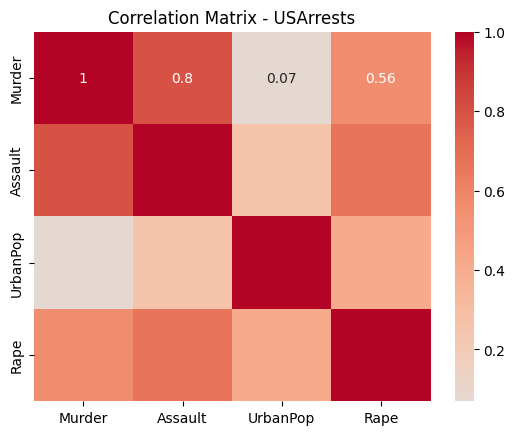

In [12]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix - USArrests')
plt.show()

In [13]:
features=['Murder','UrbanPop','Rape']

In [14]:
df_selected = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected)
print(X_scaled.shape)

(50, 3)


In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_, pca.explained_variance_ratio_.sum())

[0.57731281 0.31126728] 0.8885800845534098


In [16]:
pd.DataFrame(pca.components_, columns=features, index=['PC1', 'PC2'])

,Murder,UrbanPop,Rape
PC1,0.573210,0.442179,0.689861
PC2,0.586889,-0.809076,0.030943


In [20]:
# WCSS for k-means
wcss = []
k_values = range(1,10)

# for loop
for k in k_values:
    kmean=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmean.fit(X_pca)
# WCSS returned
    wcss.append(kmean.inertia_)
round(np.mean(wcss),2)

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Wi

41.99

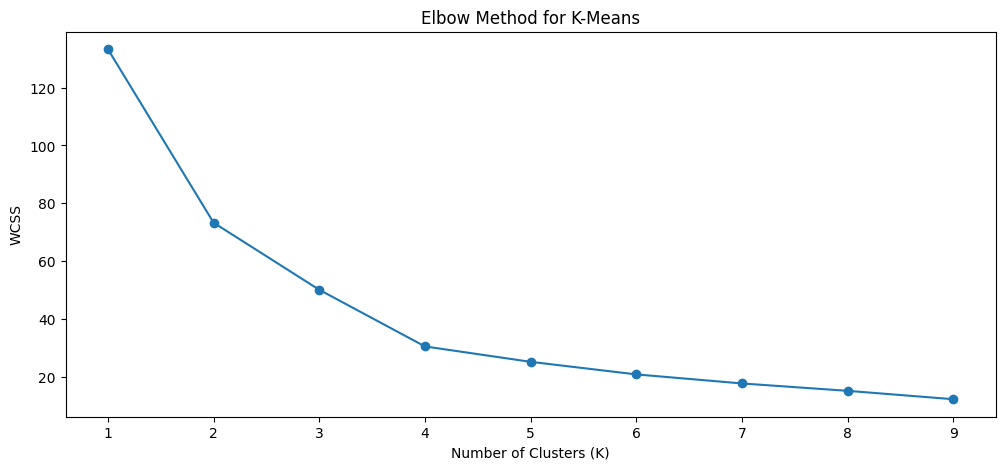

In [18]:
fig,axes=plt.subplots(figsize=(12,5))
axes.plot(k_values,wcss,marker='o',linestyle='-')
axes.set_xlabel("Number of Clusters (K)")
axes.set_ylabel("WCSS")
axes.set_title("Elbow Method for K-Means")

plt.show()

In [19]:
bic_scores = []

# for loop
for n in range(1,10):
    gmm=GaussianMixture(n_components=n,random_state=42,n_init=10)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))


c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Wi

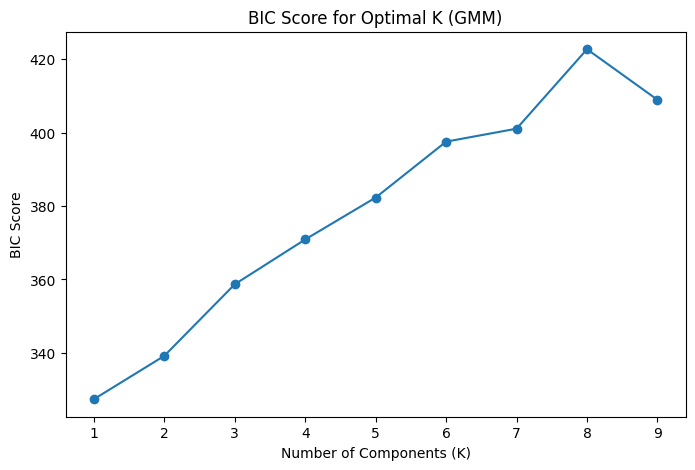

In [21]:
plt.figure(figsize=(8,5))
plt.plot(k_values, bic_scores, marker='o', linestyle='-')
plt.xlabel("Number of Components (K)")
plt.ylabel("BIC Score")
plt.title("BIC Score for Optimal K (GMM)")
plt.show()

In [22]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

gmm = GaussianMixture(n_components=optimal_k, random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(X_pca)
gmm_probs = gmm.predict_proba(X_pca).max(axis=1)

c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Wi

In [23]:
df['KMeans_Cluster'] = kmeans_labels
df['GMM_Cluster'] = gmm_labels
df['GMM_Probability'] = gmm_probs

In [24]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum())
df.describe()

(50, 7)
Murder             float64
Assault              int64
UrbanPop             int64
Rape               float64
KMeans_Cluster       int32
GMM_Cluster          int64
GMM_Probability    float64
dtype: object
Murder             0
Assault            0
UrbanPop           0
Rape               0
KMeans_Cluster     0
GMM_Cluster        0
GMM_Probability    0
dtype: int64


,Murder,Assault,UrbanPop,Rape,KMeans_Cluster,GMM_Cluster,GMM_Probability
count,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000,0.920000,0.680000,0.942618
std,4.35551,83.337661,14.474763,9.366385,0.804071,0.843704,0.097678
min,0.80000,45.000000,32.000000,7.300000,0.000000,0.000000,0.590448
25%,4.07500,109.000000,54.500000,15.075000,0.000000,0.000000,0.932525
50%,7.25000,159.000000,66.000000,20.100000,1.000000,0.000000,0.986712
75%,11.25000,249.000000,77.750000,26.175000,2.000000,1.000000,0.999429
max,17.40000,337.000000,91.000000,46.000000,2.000000,2.000000,0.999999


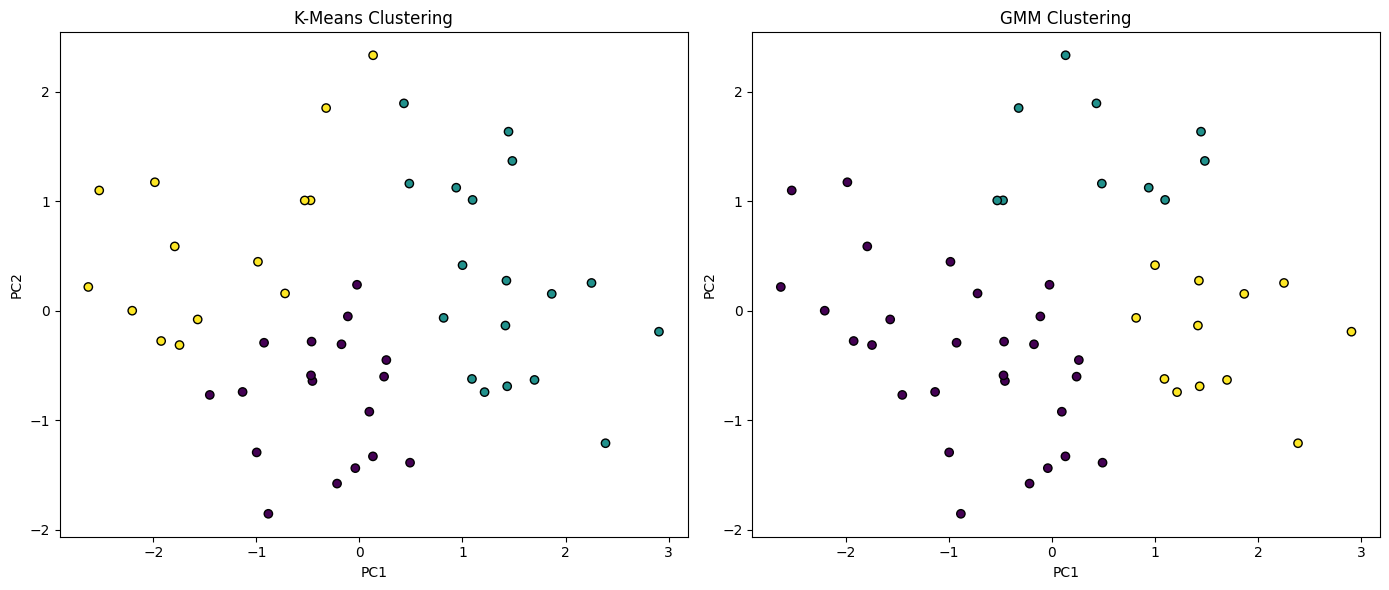

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['KMeans_Cluster'],
                cmap='viridis', marker='o', edgecolor='k')
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("K-Means Clustering")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['GMM_Cluster'],
                cmap='viridis', marker='o', edgecolor='k')
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("GMM Clustering")

plt.tight_layout()
plt.show()